# Women Safety ML Project — Data Analysis & Preprocessing

**Workflow followed:**  
`Raw Dataset → Load Dataset → Basic Data Understanding → Data Analysis + Visualization → Data Cleaning → Missing Values → Outlier Analysis → Categorical Encoding → Feature Scaling → ML Ready`

This notebook follows the uploaded **Machine Learning Project Workflow** documentation. The documentation recommends `SimpleImputer` for missing values, IQR for outlier investigation, `OrdinalEncoder`/`OneHotEncoder` for categorical variables, and `StandardScaler`/`MinMaxScaler` for scaling. 


## 1. Import Libraries and Load Dataset

The dataset is loaded with Pandas as specified in the workflow documentation.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

# Update this path if the CSV is stored in another location.
DATA_PATH = "women_safety_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,id,location,city,latitude,longitude,road_type,lighting_score,crowd_density_score,police_presence_score,cctv_coverage_score,historical_crime_count,emergency_access_score,crime_type,risk_score,risk_level,safe_route_score,safe_route_path,voice_detected,voice_phrase,voice_event_type,recommended_action
0,1,"Main Road, Hyderabad",Hyderabad,17.402385,78.481861,Main Road,5,4,3,2,94,2,Theft,56.32,Medium,53.82,"17.406193,78.481276 -> 17.4018,78.485809 -> 17...",True,help,Help,Trigger emergency alert and share location
1,2,"Main Road, Visakhapatnam",Visakhapatnam,17.697799,83.186719,Main Road,2,4,3,8,77,1,Stalking,54.52,Medium,47.12,"17.701463,83.186155 -> 17.697968,83.183157 -> ...",True,save me,Help,Trigger emergency alert and share location
2,3,"Bus Stop Area, Delhi",Delhi,28.642689,77.166270,Bus Stop Area,8,10,4,0,97,3,NaN,42.70,Medium,66.74,"28.63779,77.16295 -> 28.643181,77.168116 -> 28...",True,call my mother,Relative,Notify selected relative
3,4,"College Road, Bengaluru",Bengaluru,12.909894,77.605943,College Road,2,2,6,1,45,6,Robbery,49.89,Medium,53.49,"12.908202,77.607472 -> 12.912471,77.608271 -> ...",True,call police,Emergency,Trigger emergency alert and share location
4,5,"Residential Street, Mumbai",Mumbai,19.073480,72.912824,Residential Street,7,2,8,4,80,10,NaN,37.27,Medium,76.94,"19.071867,72.913727 -> 19.077325,72.912734 -> ...",True,dad,Relative,Notify selected relative


## 2. Basic Data Understanding

In [4]:
print("Shape:", df.shape)
print("\nData types and non-null counts:")
df.info()


Shape: (1000, 21)

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1000 non-null   int64  
 1   location                1000 non-null   str    
 2   city                    1000 non-null   str    
 3   latitude                1000 non-null   float64
 4   longitude               1000 non-null   float64
 5   road_type               1000 non-null   str    
 6   lighting_score          1000 non-null   int64  
 7   crowd_density_score     1000 non-null   int64  
 8   police_presence_score   1000 non-null   int64  
 9   cctv_coverage_score     1000 non-null   int64  
 10  historical_crime_count  1000 non-null   int64  
 11  emergency_access_score  1000 non-null   int64  
 12  crime_type              661 non-null    str    
 13  risk_score              1000 non-null   float64
 14  r

In [5]:
print("Descriptive statistics:")
display(df.describe(include="all").T)


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
location,1000,64,"Main Road, Vijayawada",23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1000,8,Vijayawada,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,1000.0,NaN,NaN,NaN,17.974392,4.551754,12.85846,16.435062,17.417083,18.996047,28.722747
longitude,1000.0,NaN,NaN,NaN,78.036846,3.199771,72.797148,77.150147,78.411419,80.599168,83.306818
road_type,1000,8,Main Road,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lighting_score,1000.0,NaN,NaN,NaN,5.575,2.827786,1.0,3.0,6.0,8.0,10.0
crowd_density_score,1000.0,NaN,NaN,NaN,5.435,2.854457,1.0,3.0,5.0,8.0,10.0
police_presence_score,1000.0,NaN,NaN,NaN,4.988,3.149568,0.0,2.0,5.0,8.0,10.0
cctv_coverage_score,1000.0,NaN,NaN,NaN,5.166,3.13373,0.0,2.0,5.0,8.0,10.0


In [6]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
display(df.nunique().sort_values(ascending=False).to_frame("unique_count"))


Missing values:


,missing_count
crime_type,339
location,0
city,0
latitude,0
id,0
longitude,0
road_type,0
crowd_density_score,0
lighting_score,0
police_presence_score,0



Duplicate rows: 0

Unique values:


,unique_count
id,1000
longitude,1000
safe_route_path,1000
latitude,999
safe_route_score,886
risk_score,724
historical_crime_count,101
location,64
cctv_coverage_score,11
police_presence_score,11


In [7]:
# Categorical frequency tables
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame("count"))



--- location ---


C:\Users\psaty\AppData\Local\Temp\ipykernel_17820\1512588293.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


,count
location,
"Main Road, Vijayawada",23
"Park Road, Pune",23
"Main Road, Pune",23
"Main Road, Mumbai",22
"Residential Street, Vijayawada",22
...,...
"Market Road, Mumbai",10
"Railway Station Road, Chennai",9
"Industrial Road, Visakhapatnam",8



--- city ---


,count
city,
Vijayawada,143
Bengaluru,129
Hyderabad,128
Mumbai,127
Delhi,125
Visakhapatnam,117
Chennai,116
Pune,115


...

,count
voice_phrase,
call my sister,116
mom,108
call my mother,105
call my father,105
help,103
dad,101
help me,99
none,99
call police,91



--- voice_event_type ---


,count
voice_event_type,
Relative,535
Help,275
No Alert,99
Emergency,91



--- recommended_action ---


,count
recommended_action,
Notify selected relative,535
Trigger emergency alert and share location,366
No action,99


## 3. Data Cleaning — Duplicate Rows

In [8]:
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print("Rows before:", before)
print("Rows after :", after)
print("Duplicates removed:", before - after)


Rows before: 1000
Rows after : 1000
Duplicates removed: 0


## 4. Visualization

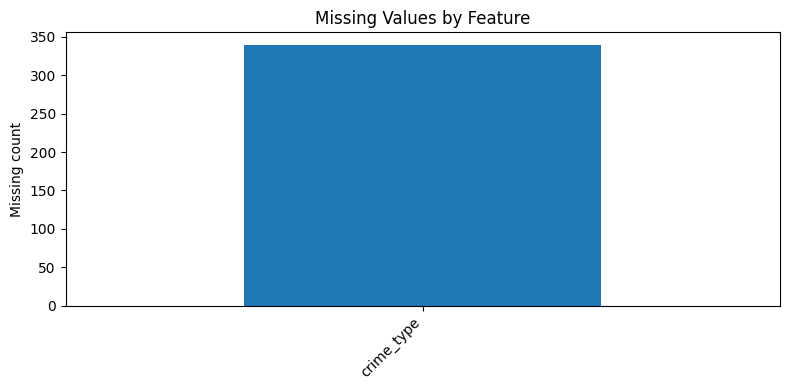

In [9]:
# Missing-value visualization
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing):
    plt.figure(figsize=(8, 4))
    missing.plot(kind="bar")
    plt.title("Missing Values by Feature")
    plt.ylabel("Missing count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


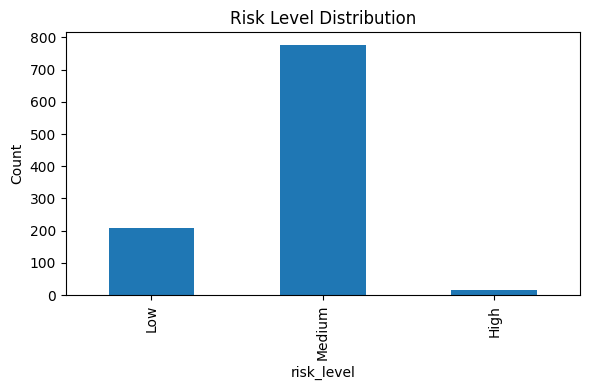

In [10]:
# Risk-level distribution
if "risk_level" in df.columns:
    order = ["Low", "Medium", "High"]
    df["risk_level"].value_counts().reindex(order).plot(kind="bar", figsize=(6, 4))
    plt.title("Risk Level Distribution")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


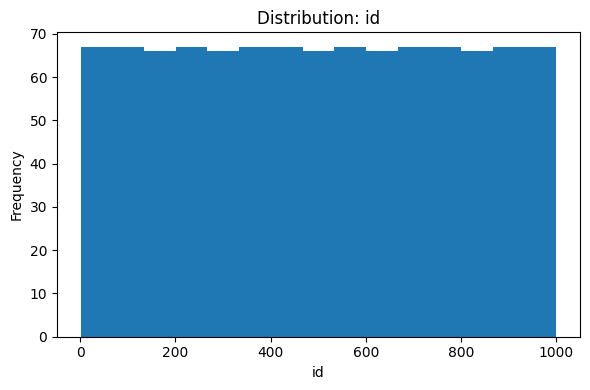

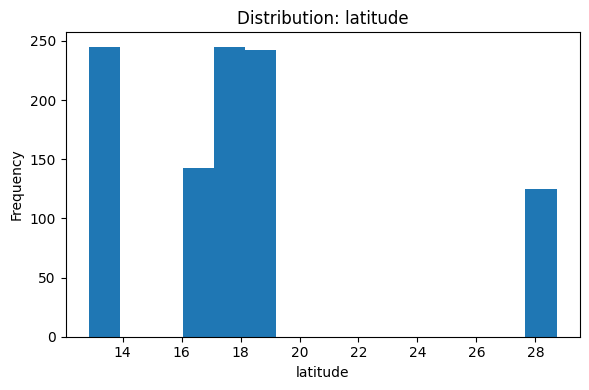

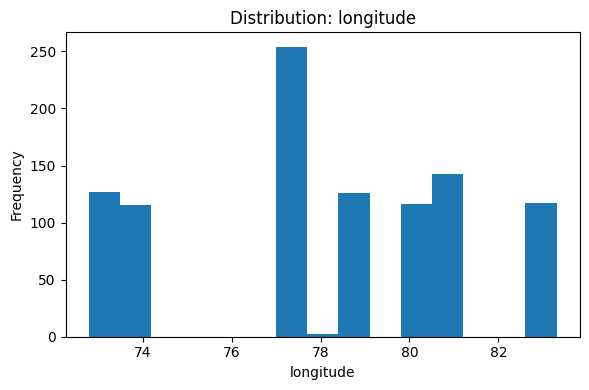

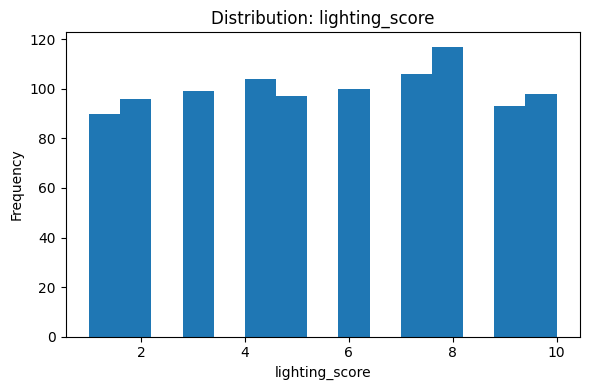

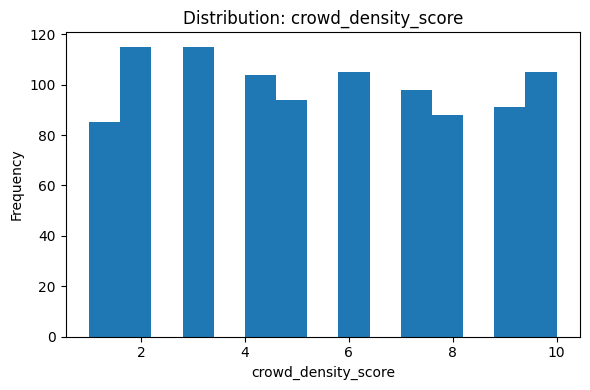

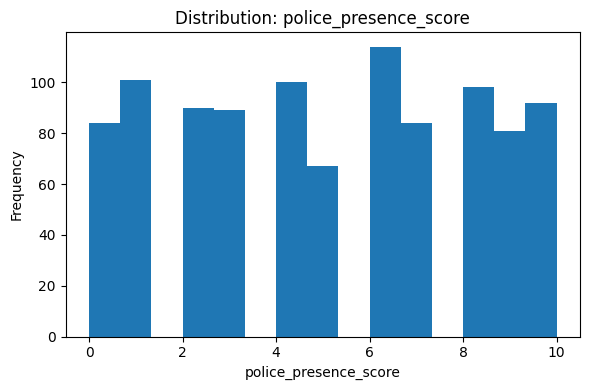

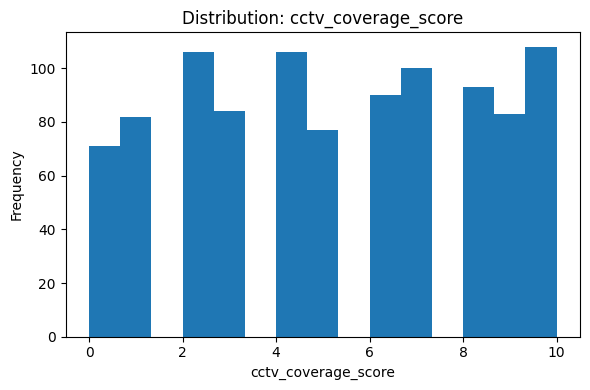

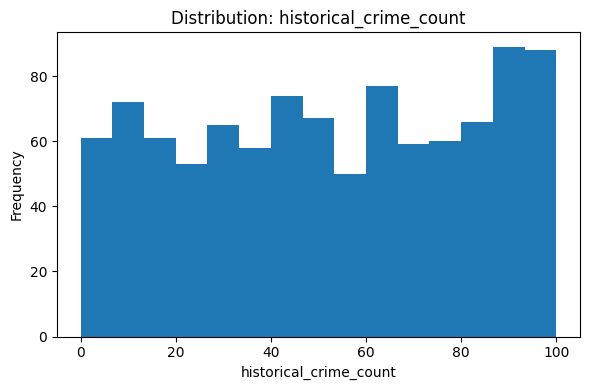

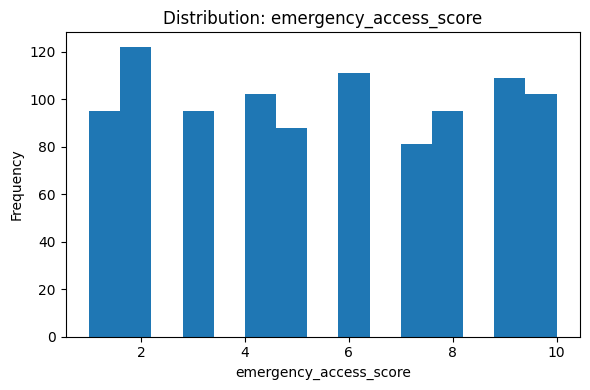

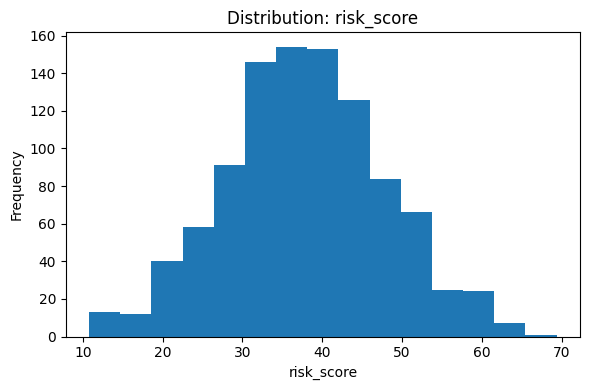

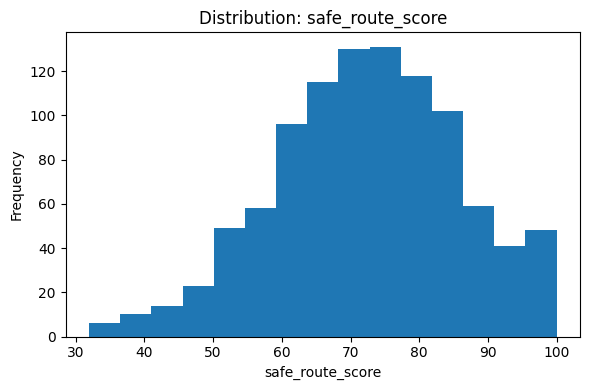

In [11]:
# Histograms for numerical variables
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].plot(kind="hist", bins=15)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


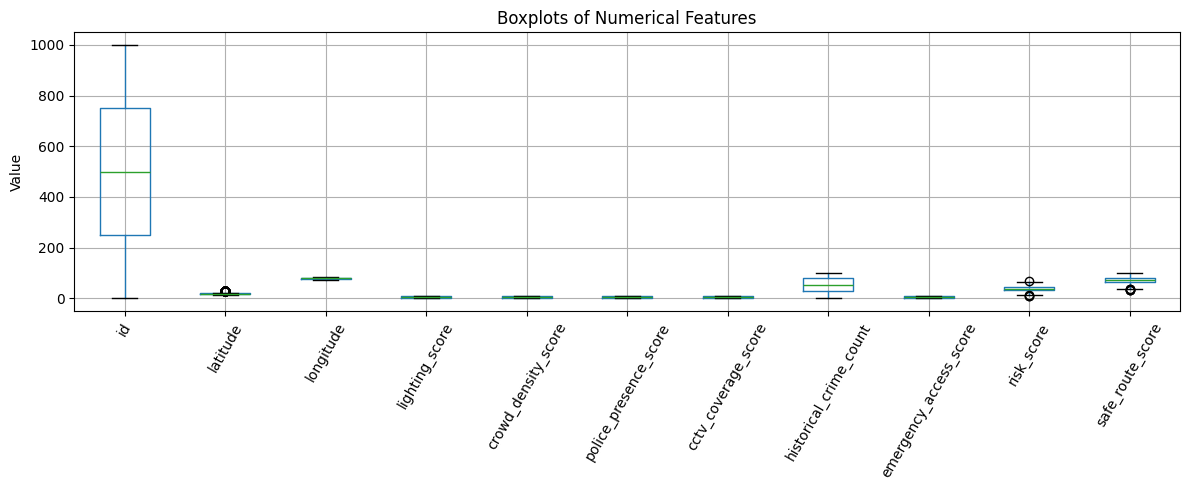

In [12]:
# Boxplots for numerical variables
if numeric_cols:
    plt.figure(figsize=(12, 5))
    df[numeric_cols].boxplot(rot=60)
    plt.title("Boxplots of Numerical Features")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()


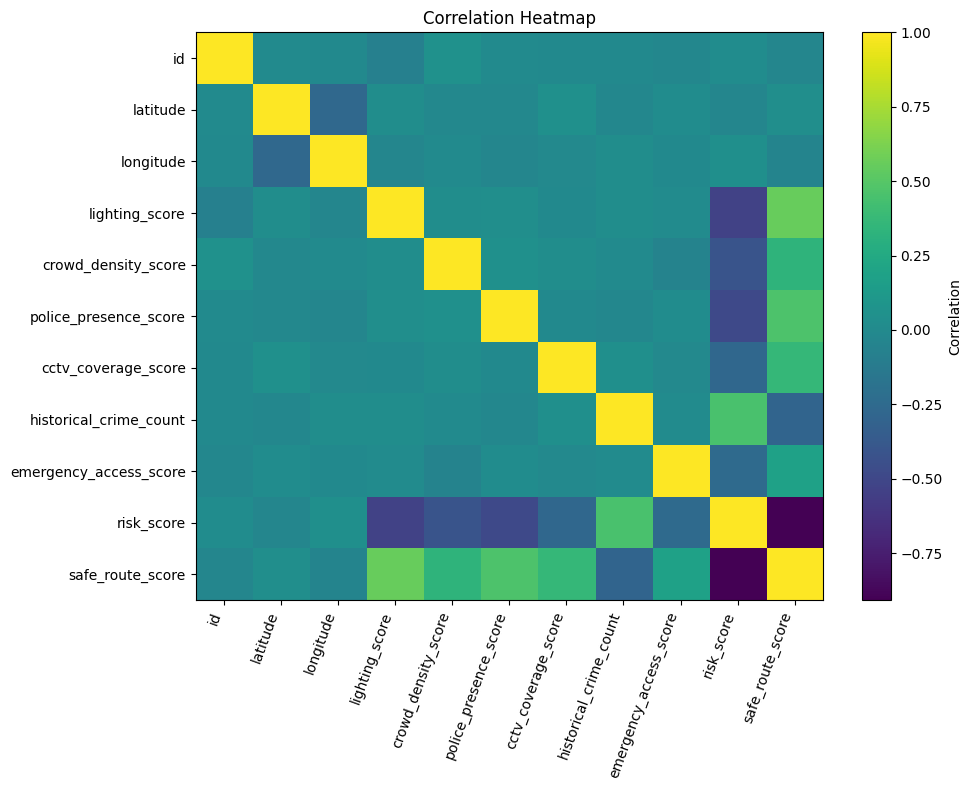

In [13]:
# Correlation heatmap using matplotlib
if numeric_cols:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=70, ha="right")
    plt.yticks(range(len(numeric_cols)), numeric_cols)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()


## 5. Missing Value Handling

Following the documentation:
- Numerical features → **median** imputation
- Categorical features → **most frequent** imputation

The documentation specifically recommends `SimpleImputer` rather than allowing missing values to reach models that cannot handle them.


### Check missing values before preprocessing

In [14]:
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_before"))


,missing_before
crime_type,339
location,0
city,0
latitude,0
id,0
longitude,0
road_type,0
crowd_density_score,0
lighting_score,0
police_presence_score,0


## 6. Outlier Analysis — IQR Method

For each numerical feature:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

The workflow documentation says outliers should be investigated before removing them, because an outlier can be a legitimate observation.


In [15]:
outlier_rows = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = int(((df[col] < lower) | (df[col] > upper)).sum())

    outlier_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count
    })

outlier_df = pd.DataFrame(outlier_rows)
display(outlier_df.sort_values("outlier_count", ascending=False))


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
1,latitude,16.435062,18.996047,2.560986,12.593583,22.837526,125
10,safe_route_score,63.390000,81.827500,18.437500,35.733750,109.483750,5
9,risk_score,31.502500,44.617500,13.115000,11.830000,64.290000,4
2,longitude,77.150147,80.599168,3.449021,71.976616,85.772700,0
0,id,250.750000,750.250000,499.500000,-498.500000,1499.500000,0
3,lighting_score,3.000000,8.000000,5.000000,-4.500000,15.500000,0
4,crowd_density_score,3.000000,8.000000,5.000000,-4.500000,15.500000,0
6,cctv_coverage_score,2.000000,8.000000,6.000000,-7.000000,17.000000,0
5,police_presence_score,2.000000,8.000000,6.000000,-7.000000,17.000000,0
8,emergency_access_score,3.000000,8.000000,5.000000,-4.500000,15.500000,0


### Outlier decision

Flagged values are **not automatically deleted**. They should first be checked as data-entry errors or legitimate observations, as required by the workflow documentation. For this dataset, the preprocessing pipeline therefore retains the observations and uses robust median imputation for missing numerical values.


## 7. Prepare Features and Candidate Target

For the safety-risk classification task, `risk_level` is used as the **candidate target**:

- Low → 0
- Medium → 1
- High → 2

`risk_score` is excluded from the input features because it directly determines the risk level in this dataset; retaining it would create target leakage.

Identifiers and raw route/location text are also excluded from this baseline feature matrix.


In [16]:
target = "risk_level"

drop_for_ml = [
    "id",
    "location",
    "safe_route_path",
    "risk_score",
    target
]

X = df.drop(columns=drop_for_ml)
y = df[target].map({"Low": 0, "Medium": 1, "High": 2})

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nTarget distribution:")
display(df[target].value_counts().to_frame("count"))


Numerical features: ['latitude', 'longitude', 'lighting_score', 'crowd_density_score', 'police_presence_score', 'cctv_coverage_score', 'historical_crime_count', 'emergency_access_score', 'safe_route_score']

Categorical features: ['city', 'road_type', 'crime_type', 'voice_detected', 'voice_phrase', 'voice_event_type', 'recommended_action']

Target distribution:


C:\Users\psaty\AppData\Local\Temp\ipykernel_17820\2092421869.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


,count
risk_level,
Medium,777
Low,207
High,16


## 8. Build the Preprocessing Pipeline

The preprocessing pipeline applies:

1. **Median imputation + StandardScaler** to numerical features.
2. **Most-frequent imputation + OneHotEncoder** to categorical features.

This keeps preprocessing reproducible and prevents inconsistent transformations later when a model is trained.


In [17]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_ready = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()
X_ready_df = pd.DataFrame(X_ready, columns=feature_names, index=X.index)

y_encoded = y.astype(int)

ml_ready = X_ready_df.copy()
ml_ready["risk_level_target"] = y_encoded.values

print("ML-ready shape:", ml_ready.shape)
display(ml_ready.head())


ML-ready shape: (1000, 52)


,num__latitude,num__longitude,num__lighting_score,num__crowd_density_score,num__police_presence_score,num__cctv_coverage_score,num__historical_crime_count,num__emergency_access_score,num__safe_route_score,cat__city_Bengaluru,cat__city_Chennai,cat__city_Delhi,cat__city_Hyderabad,cat__city_Mumbai,cat__city_Pune,cat__city_Vijayawada,cat__city_Visakhapatnam,cat__road_type_Bus Stop Area,cat__road_type_College Road,cat__road_type_Industrial Road,cat__road_type_Main Road,cat__road_type_Market Road,cat__road_type_Park Road,cat__road_type_Railway Station Road,cat__road_type_Residential Street,cat__crime_type_Abduction,cat__crime_type_Assault,cat__crime_type_Harassment,cat__crime_type_Robbery,cat__crime_type_Sexual Harassment,cat__crime_type_Stalking,cat__crime_type_Theft,cat__voice_detected_False,cat__voice_detected_True,cat__voice_phrase_call my father,cat__voice_phrase_call my mother,cat__voice_phrase_call my sister,cat__voice_phrase_call police,cat__voice_phrase_dad,cat__voice_phrase_help,cat__voice_phrase_help me,cat__voice_phrase_mom,cat__voice_phrase_none,cat__voice_phrase_save me,cat__voice_event_type_Emergency,cat__voice_event_type_Help,cat__voice_event_type_No Alert,cat__voice_event_type_Relative,cat__recommended_action_No action,cat__recommended_action_Notify selected relative,cat__recommended_action_Trigger emergency alert and share location,risk_level_target
0,-0.125730,0.139147,-0.203441,-0.502974,-0.631514,-1.010803,1.407414,-1.191154,-1.376830,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
1,-0.060797,1.610256,-1.264873,-0.502974,-0.631514,0.904806,0.835841,-1.534822,-1.872337,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
2,2.344950,-0.272211,0.857991,1.600054,-0.313851,-1.649340,1.508279,-0.847486,-0.421314,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
3,-1.113204,-0.134734,-1.264873,-1.203984,0.321475,-1.330071,-0.240061,0.183519,-1.401236,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,0.241585,-1.602173,0.504180,-1.203984,0.956800,-0.372267,0.936707,1.558191,0.333040,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1


## 9. Verify Preprocessing Results

In [18]:
print("Missing values in ML-ready data:", int(ml_ready.isnull().sum().sum()))
print("ML-ready rows:", ml_ready.shape[0])
print("ML-ready features including target:", ml_ready.shape[1])

print("\nTarget distribution:")
display(y_encoded.value_counts().sort_index().rename(index={0:"Low", 1:"Medium", 2:"High"}).to_frame("count"))


Missing values in ML-ready data: 0
ML-ready rows: 1000
ML-ready features including target: 52

Target distribution:


,count
risk_level,
Low,207
Medium,777
High,16


In [19]:
# Numerical transformed features should have approximately mean 0 and std 1.
scaled_cols = [c for c in ml_ready.columns if c.startswith("num__")]

if scaled_cols:
    scaling_check = pd.DataFrame({
        "mean": ml_ready[scaled_cols].mean(),
        "std": ml_ready[scaled_cols].std(ddof=0)
    })
    display(scaling_check.head(20))


,mean,std
num__latitude,3.286260e-17,1.0
num__longitude,1.106670e-15,1.0
num__lighting_score,-2.486900e-17,1.0
num__crowd_density_score,1.136868e-16,1.0
num__police_presence_score,-1.101341e-16,1.0
num__cctv_coverage_score,-1.056932e-16,1.0
num__historical_crime_count,-1.776357e-17,1.0
num__emergency_access_score,-1.305622e-16,1.0
num__safe_route_score,6.572520e-16,1.0


## 10. Save the Preprocessed Dataset

The resulting CSV is ready to be used in the next stage: train/test split and ML model training.


In [20]:
OUTPUT_PATH = "ml_ready_dataset.csv"
ml_ready.to_csv(OUTPUT_PATH, index=False)

OUTLIER_PATH = "outlier_analysis.csv"
outlier_df.to_csv(OUTLIER_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Saved: {OUTLIER_PATH}")


Saved: ml_ready_dataset.csv
Saved: outlier_analysis.csv


# Preprocessing Complete ✅

**Completed:**  
Load Dataset → Understand Data → Data Analysis → Visualization → Handle Missing Values → Analyze Outliers → Encode Categorical Data → Scale Numerical Features → ML Ready

**Next stage:** Train/test split, model training, evaluation, and model comparison.
